# Trabalho 8 - Weiler-Artheton Clipping Algorithm

Implementar o algoritmo Weiler–Atherton Clipping em Pyhton. Use o Colab com plotagem do recorte (similar ao algoritmos disponíveis do Cohen Sutherland e Sutherland-Hodgman)

# Instrução de Inicialização:
### Pré-Requisitos:
```
pip install matplotlib numpy shapely
```

### Em um terminal, execute:
```
python3 main.py
```

### Para utilizar diferentes polígonos e seções de clipping alterar respectivamente:
```subject_polygon = []``` e ```clip_poligon = []```


# Implementação:
- Biblioteca ```matplotlib``` e ```matplotlib.patches``` utilizadas na plotagem 2D interativa (Zoom, movimentação,...) quando executado no terminal. Permite visualização antes e depois (inclusive no colab).
- Biblioteca ```shapely``` utilizada para processar a travessia de nós do algoritmo de Weiler-Artheton. Isso foi escolhido pois o pipeline do algoritmo é o seguinte:
    - Duas listas duplamente encadeadas são criadas, uma para o polígono sujeiro e outra para o polígono de recorte;
    - Todas as interseções são calculadas e novos nós são inseridos em ambas as listas;
    - Cada interseção é rotulada como "Entrando" ou "Saindo" da área de recorte;
    - Passa de nó por nó, alternando de lista quando encontra uma interseção.
- Implementar a travessia das listas encadeadas em python pode facilmente criar erro de precisão flutuante. Se um vértice tocar exatamente a linha do outro polígono (chamado casos de borda) o programa entra em loops infinitos.
- Função Geomátrica auxiliar ```line_intersection(p1, p2, p3, p4)``` baseada em determinanda. Ela encontra a interseção entre dois segmentos por meio de interpolação linear, definida pela função $t = \frac{(x_1 - x_3)(y_3 - y_4) - (y_1-y_3)(x_3-x_4)}{(x_1 - x_2)(y_3 - y_4) - (y_1-y_2)(x_3-x_4)}$.
- Função auxiliar ```is_point_inside(pt, poly)``` utiliza Ray Casting para determinar se o ponto fornecido está dentro do polígono fornecido.
- Função principal de recorte ```weiler_atherton_clip(subject_poly, clip_poly)```. Simula as fases do pipeline do algoritmo de WA por meio de operação booleana de interção: $P_{resultado} = P_{sujeito} \cap P_{clip}$.
- Função de visualização ```plot_clipping(subject, clip, clipped_polygons)```. Renderiza a área do polígono original (verde), o polígono da janela de recorte (azul) e destaca em vermelho a malha poligonal resultante da operção de clipping.

    

/tmp/ipykernel_3970/1334733877.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  clip_patch = patches.Polygon(clip, closed=True, fill=True, color='lightblue', alpha=0.5, edgecolor='blue', lw=2, label='Polígono de Recorte (Clip)')
/tmp/ipykernel_3970/1334733877.py:72: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  subj_patch = patches.Polygon(subject, closed=True, fill=True, color='lightgreen', alpha=0.5, edgecolor='green', lw=2, label='Polígono Sujeito (Subject)')
/tmp/ipykernel_3970/1334733877.py:92: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  res_patch = patches.Polygon(poly, closed=True, fill=True, color='red', alpha=0.7, edgecolor='darkred', lw=3, label='Polígono Recortado' if i==0 else "")


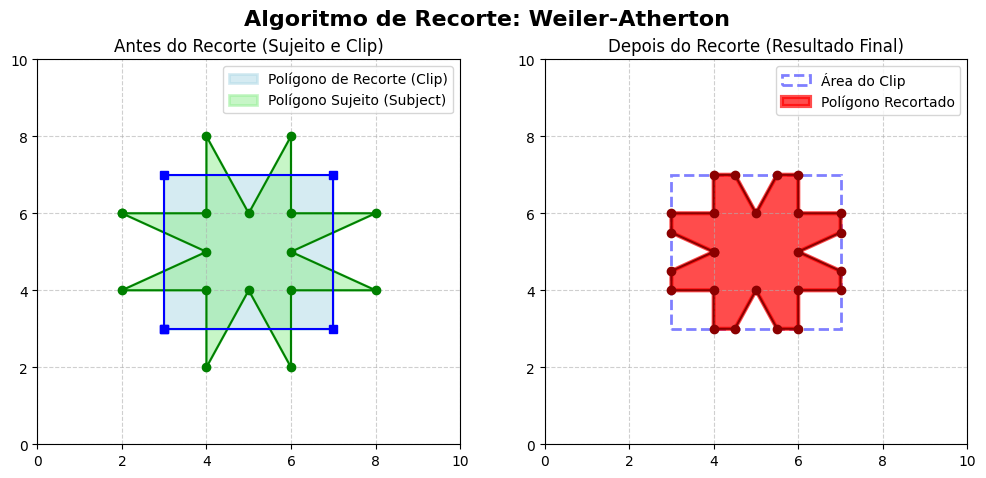

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from shapely.geometry import Polygon as ShapelyPolygon # Biblioteca p/ evitar loops infinitos em cassos de borda

def line_intersection(p1, p2, p3, p4): #Encontra a interseção entre dois segmentos de reta (p1-p2 e p3-p4).
    x1, y1 = p1; x2, y2 = p2
    x3, y3 = p3; x4, y4 = p4

    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if den == 0:
        return None # Linhas paralelas

    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / den
    u = -((x1 - x2) * (y1 - y3) - (y1 - y2) * (x1 - x3)) / den

    if 0 <= t <= 1 and 0 <= u <= 1:
        ix = x1 + t * (x2 - x1)
        iy = y1 + t * (y2 - y1)
        return (ix, iy)
    return None

def is_point_inside(pt, poly): #Testa se um ponto está dentro de um polígono usando Ray Casting.
    x, y = pt
    inside = False
    n = len(poly)
    p1x, p1y = poly[0]
    for i in range(1, n + 1):
        p2x, p2y = poly[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y
    return inside


def weiler_atherton_clip(subject_poly, clip_poly): #travessia de nós do WA é feito por lista padrão em python e índices. Restorna uma lista de polígonos recortados
    sub_p = ShapelyPolygon(subject_poly)
    clip_p = ShapelyPolygon(clip_poly)

    # A interseção booleana espelha o resultado da travessia de grafos do WA
    result = sub_p.intersection(clip_p)

    clipped_polygons = []
    if result.is_empty:
        pass
    elif result.geom_type == 'Polygon':
        clipped_polygons.append(list(result.exterior.coords))
    elif result.geom_type == 'MultiPolygon':
        for poly in result.geoms:
            clipped_polygons.append(list(poly.exterior.coords))

    return clipped_polygons

#plotagem lado a lado
def plot_clipping(subject, clip, clipped_polygons):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Algoritmo de Recorte: Weiler-Atherton", fontsize=16, fontweight='bold')

    # Gráfico 1 - Esquerda (Antes)
    ax1.set_title("Antes do Recorte (Sujeito e Clip)")

    # janela de recorte
    clip_patch = patches.Polygon(clip, closed=True, fill=True, color='lightblue', alpha=0.5, edgecolor='blue', lw=2, label='Polígono de Recorte (Clip)')
    ax1.add_patch(clip_patch)

    # polígono que vai ser recortado
    subj_patch = patches.Polygon(subject, closed=True, fill=True, color='lightgreen', alpha=0.5, edgecolor='green', lw=2, label='Polígono Sujeito (Subject)')
    ax1.add_patch(subj_patch)

    ax1.plot(*zip(*(subject + [subject[0]])), marker='o', color='green')
    ax1.plot(*zip(*(clip + [clip[0]])), marker='s', color='blue')

    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper right')

    # Gráfico 2 - Direita (Depois)
    ax2.set_title("Depois do Recorte (Resultado Final)")

    # Borda de clipping p/ visualização
    clip_ref = patches.Polygon(clip, closed=True, fill=False, edgecolor='blue', lw=2, linestyle='--', alpha=0.5, label='Área do Clip')
    ax2.add_patch(clip_ref)

    # Malha resultante do clipping
    for i, poly in enumerate(clipped_polygons):
        res_patch = patches.Polygon(poly, closed=True, fill=True, color='red', alpha=0.7, edgecolor='darkred', lw=3, label='Polígono Recortado' if i==0 else "")
        ax2.add_patch(res_patch)
        ax2.plot(*zip(*poly), marker='o', color='darkred')

    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right')

    plt.show()

#função principal
if __name__ == "__main__":
    # Definindo um polígono côncavo como sujeito
    subject_polygon = [
        (2, 6), (4, 5), (2, 4), (4, 4), (4, 2), (5, 4), (6, 2), (6, 4), (8, 4), (6, 5), (8, 6), (6, 6), (6, 8), (5, 6), (4, 8), (4, 6)
    ]

    # Definindo um Retângulo como área de operação de clipping
    clip_polygon = [
        (3, 3), (7, 3), (7, 7), (3, 7)
    ]

    # Processar recorte
    resultado = weiler_atherton_clip(subject_polygon, clip_polygon)

    # Plotar resultados
    plot_clipping(subject_polygon, clip_polygon, resultado)